I want to predict all the times for one store

In [1]:
# Add project root to path so we can import from data_manipulation and model
import sys
from pathlib import Path

def _find_project_root():
    cwd = Path.cwd()
    if (cwd / "data_manipulation").is_dir():
        return cwd
    if (cwd.parent / "data_manipulation").is_dir():
        return cwd.parent
    return cwd  # fallback

project_root = _find_project_root()
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

In [2]:
import torch
from torch import nn
import matplotlib.pyplot as plt
from functools import partial

# Imports from data_manipulation and model
from data_manipulation.data_split import create_dataloader, DemandDataset
from model.functions import pinball_loss, rmse, train, get_test_loss

In [3]:
class simple_net(nn.Module):
    def __init__(self,input_size, hidden_size=10, output_size=1):
        super().__init__()
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.fc2 = nn.Linear(hidden_size, hidden_size)
        self.fc3 = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        x = self.fc3(x)
        return x

In [4]:
all_specs = [
    '6_day_lag', 
    '180_day_rolling_mean', 
    '90_day_rolling_volatility', 
    '90_day_rolling_ema', 
    'diff_30_day', 
    '7_day_rolling_mean', 
    '3_day_lag', 
    'circular_sin_cos_day_of_week', 
    '180_day_rolling_min', 
    'diff_365_day', 
    'one_hot_month', 
    '30_day_rolling_mean', 
    'circular_sin_cos_week', 
    '5_day_lag', 
    '180_day_rolling_ema']

In [5]:
# Get data for spec
train_loader, val_loader, test_loader = create_dataloader(
    batch_size=8, 
    test_batch_size=1,
    pin_memory=False,
    data_mask=[
        ("item", 1)
    ],
    specs=all_specs,
    combine_items=True
    )

/home/normski/Code/BYU_Classes/Demand_NN/data_manipulation/data_creation.py:745: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[out_col] = df.groupby("item")[col].shift(period)
/home/normski/Code/BYU_Classes/Demand_NN/data_manipulation/data_creation.py:766: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[out_col] = df[col] - shifted


In [6]:
h_cost = 1
l_cost = 3

net = simple_net(train_loader.dataset.x.shape[1], hidden_size=train_loader.dataset.x.shape[1], output_size=train_loader.dataset.y.shape[1])
loss = partial(pinball_loss, h_cost=h_cost, l_cost=l_cost)
optimizer = torch.optim.Adam(net.parameters(), lr=0.001)

train_losses, val_losses = train(net, optimizer, loss, train_loader, val_loader, epochs=500, eval_interval=10, device="cpu")

test_loss = get_test_loss(net, test_loader, loss, "cpu")

Training: 100%|██████████| 500/500 [00:07<00:00, 63.93step/s, train_loss=4.7630]                  


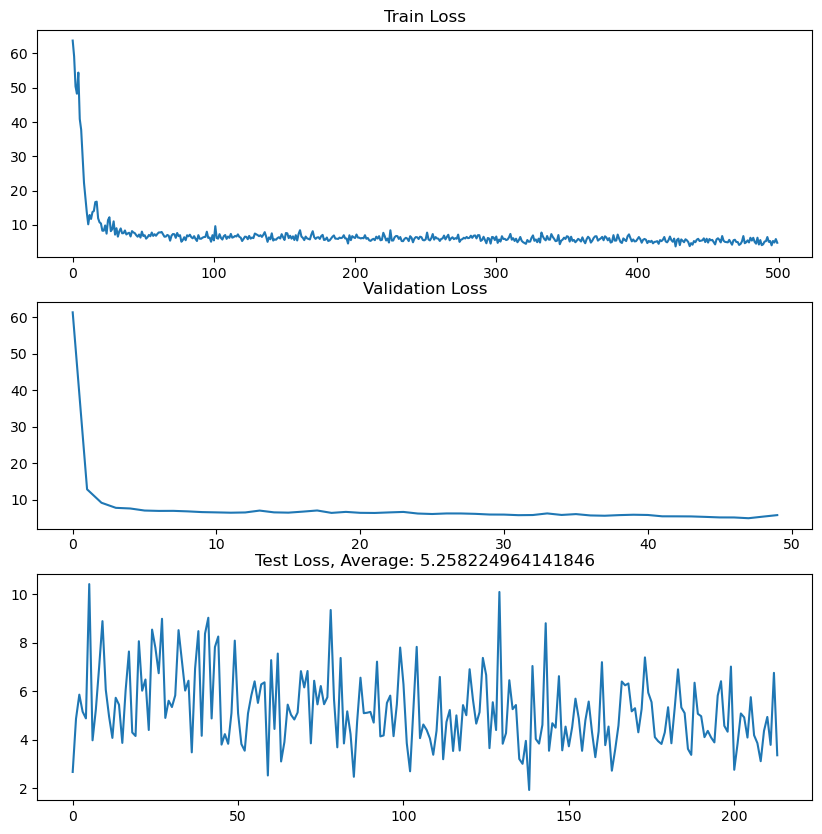

In [7]:
fig, axs = plt.subplots(3, 1, figsize=(10, 10))
axs[0].plot(train_losses)
axs[0].set_title("Train Loss")
axs[1].plot(val_losses)
axs[1].set_title("Validation Loss")
axs[2].plot(test_loss)
axs[2].set_title(f"Test Loss, Average: {torch.tensor(test_loss).mean()}")
plt.show()